# Final Paper Plots

Compact two-panel figure for the amplitude-damping comparison. The left panel shows one PI code under several AD scenarios. The right panel compares global/local symmetric AD performance across codes.


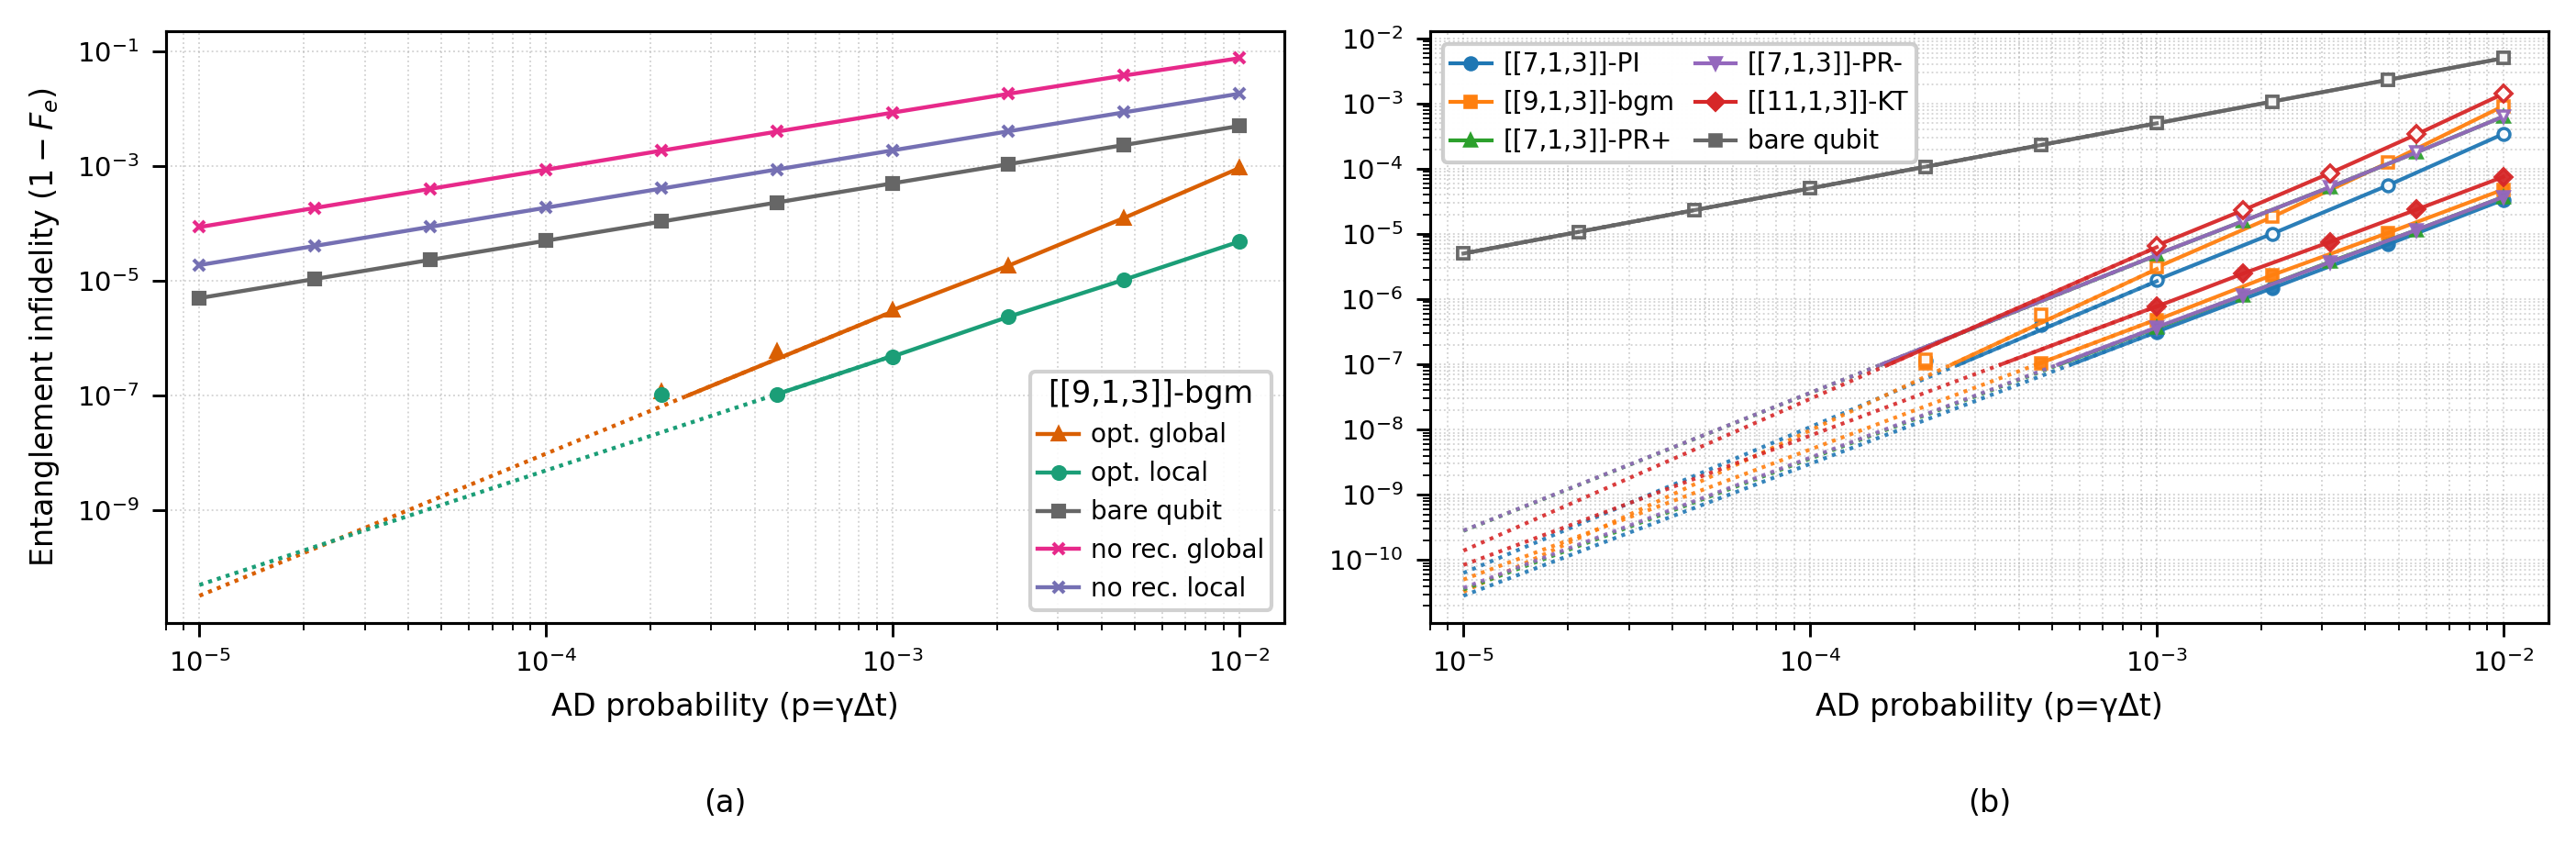

Saved /Users/46668993/Desktop/qer/plots/final_paper/fig1_amp_damp_summary.pdf
Saved /Users/46668993/Desktop/qer/plots/final_paper/fig1_amp_damp_summary.png


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------------------------------------------------------
# Paths and data
# -----------------------------------------------------------------------------
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "datas").exists())
data_dir = repo_root / "datas"
plot_dir = repo_root / "plots" / "final_paper"
plot_dir.mkdir(parents=True, exist_ok=True)

local = pd.read_csv(data_dir / "local_amp_damp_results.csv")
global_ = pd.read_csv(data_dir / "global_amp_damp_results.csv")
local_new = pd.read_csv(data_dir / "local_amp_damp_new_codes_results.csv")
global_new = pd.read_csv(data_dir / "global_amp_damp_new_codes_results.csv")

# -----------------------------------------------------------------------------
# Plot style
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 6.7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.45,
    "ytick.minor.width": 0.45,
    "lines.linewidth": 1.15,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

P_COLUMN = "gamma_dt"
FIT_THRESHOLD = 5e-4
FIT_SOURCE_MIN = 1e-3
EXTRAPOLATE_TO = 1e-5
MIN_FIT_POINTS = 3
DOTTED_BELOW_Y = 1e-7

# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------

def sorted_positive_series(frame, column):
    data = frame[[P_COLUMN, column]].dropna()
    p = data[P_COLUMN].to_numpy(dtype=float)
    y = data[column].to_numpy(dtype=float)
    valid = np.isfinite(p) & np.isfinite(y) & (p > 0) & (y > 0)
    p, y = p[valid], y[valid]
    order = np.argsort(p)
    return p[order], y[order]


def high_p_fit(p, y, source_min=FIT_SOURCE_MIN):
    mask = p >= source_min
    if np.count_nonzero(mask) < MIN_FIT_POINTS:
        return None
    return np.polyfit(np.log10(p[mask]), np.log10(y[mask]), 1)


def plot_fit_by_y_threshold(ax, p, y, *, color, lw=1.0, alpha=1.0, threshold=DOTTED_BELOW_Y):
    p = np.asarray(p, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(p) & np.isfinite(y) & (p > 0) & (y > 0)
    p, y = p[valid], y[valid]
    if p.size < 2:
        return

    for i in range(p.size - 1):
        p0, p1 = p[i], p[i + 1]
        y0, y1 = y[i], y[i + 1]
        if (y0 < threshold) == (y1 < threshold):
            style = ":" if y0 < threshold else "-"
            ax.loglog([p0, p1], [y0, y1], color=color, linestyle=style, lw=lw, alpha=alpha)
            continue

        logp0, logp1 = np.log10(p0), np.log10(p1)
        logy0, logy1 = np.log10(y0), np.log10(y1)
        frac = (np.log10(threshold) - logy0) / (logy1 - logy0)
        pc = 10 ** (logp0 + frac * (logp1 - logp0))
        style0 = ":" if y0 < threshold else "-"
        style1 = ":" if y1 < threshold else "-"
        ax.loglog([p0, pc], [y0, threshold], color=color, linestyle=style0, lw=lw, alpha=alpha)
        ax.loglog([pc, p1], [threshold, y1], color=color, linestyle=style1, lw=lw, alpha=alpha)


def plot_with_low_p_fit(ax, p, y, *, color, marker, label=None, fit_low=True, ms=3.2, lw=1.05):
    p = np.asarray(p, dtype=float)
    y = np.asarray(y, dtype=float)

    # remove plotting of individual points below threshold; keep fits/extrapolations
    visible_mask = y >= DOTTED_BELOW_Y
    high_mask = (p >= FIT_THRESHOLD) & visible_mask
    low_mask = (p < FIT_THRESHOLD) & visible_mask

    if fit_low:
        # plot visible actual data points only
        if np.any(high_mask):
            ax.loglog(p[high_mask], y[high_mask], color=color, marker=marker, linestyle="-", ms=ms, lw=lw, label=label)
        if np.any(low_mask):
            ax.loglog(p[low_mask], y[low_mask], color=color, marker=marker, linestyle="None", ms=ms, lw=lw)

        coeff = high_p_fit(p, y)
        if coeff is not None:
            fit_end = p[p >= FIT_THRESHOLD].min() if np.any(p >= FIT_THRESHOLD) else FIT_THRESHOLD
            # always extrapolate down to EXTRAPOLATE_TO so dotted extrapolation is visible
            start_p = EXTRAPOLATE_TO
            if fit_end > start_p:
                p_fit = np.logspace(np.log10(start_p), np.log10(fit_end), 80)
                y_fit = 10 ** np.polyval(coeff, np.log10(p_fit))
                # draw fitted/extrapolated lines only (no markers)
                plot_fit_by_y_threshold(ax, p_fit, y_fit, color=color, lw=lw)
    else:
        # no special low-p fit handling; plot only visible points connected
        vis = visible_mask
        if np.any(vis):
            ax.loglog(p[vis], y[vis], color=color, marker=marker, linestyle="-", ms=ms, lw=lw, label=label)

# -----------------------------------------------------------------------------
# Figure
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.0), dpi=300)
ax0, ax1 = axes

# -----------------------------------------------------------------------------
# Left panel: several AD scenarios for one PI code
# -----------------------------------------------------------------------------
left_specs = [
    (global_, "bgm_optimal", "opt. global", "#d95f02", "^", True),
    (local, "bgm_optimal", "opt. local", "#1b9e77", "o", True),
    (local, "bare_optimal", "bare qubit", "#666666", "s", False),
    (global_, "bgm_no_recovery", "no rec. global", "#e7298a", "x", False),
    (local, "bgm_no_recovery", "no rec. local", "#7570b3", "x", False),
]

for frame, column, label, color, marker, use_fit in left_specs:
    p, y = sorted_positive_series(frame, column)
    plot_with_low_p_fit(ax0, p, y, color=color, marker=marker, label=label, fit_low=use_fit, ms=3.1, lw=1.05)

ax0.set_xlim(8e-6, 1.35e-2)
#ax0.set_ylim(1e-10, 1.0)
ax0.set_xlabel("AD probability (p=γΔt)")
ax0.set_ylabel("Entanglement infidelity $(1-F_e)$")
ax0.legend(
    loc="lower right", frameon=True, framealpha=0.9, ncol=1,
    title="[[9,1,3]]-bgm", handlelength=1.6,
    handletextpad=0.45, borderpad=0.3,
)
ax0.grid(True, which="both", ls=":", lw=0.45, alpha=0.55)
ax0.text(0.5, -0.28, r"(a)", transform=ax0.transAxes, ha="center", va="top")

# -----------------------------------------------------------------------------
# (b) Global/local symmetric AD comparison across codes
# -----------------------------------------------------------------------------
frames = {
    "base": {"local": local, "global": global_},
    "new": {"local": local_new, "global": global_new},
}
code_specs = [
    {"prefix": "seven", "label": "[[7,1,3]]-PI", "source": "base", "color": "#1f77b4", "marker": "o", "linestyle": "-"},
    {"prefix": "bgm", "label": "[[9,1,3]]-bgm", "source": "base", "color": "#ff7f0e", "marker": "s", "linestyle": "--"},
    {"prefix": "pr7_plus", "label": "[[7,1,3]]-PR+", "source": "new", "color": "#2ca02c", "marker": "^", "linestyle": "-."},
    {"prefix": "pr7_minus", "label": "[[7,1,3]]-PR-", "source": "new", "color": "#9467bd", "marker": "v", "linestyle": ":"},
    {"prefix": "kt11", "label": "[[11,1,3]]-KT", "source": "new", "color": "#d62728", "marker": "D", "linestyle": (0, (3, 1, 1, 1))},
    {"prefix": "bare", "label": "bare qubit", "source": "base", "color": "#666666", "marker": "s", "linestyle": "-"},
]
# In panel (b), code identity is encoded by marker/linestyle; noise type is encoded
# by marker fill: filled markers are local symmetric AD, open markers are global symmetric AD.

for spec in code_specs:
    for noise in ["local", "global"]:
        frame = frames[spec["source"]][noise]
        column = f"{spec['prefix']}_optimal"
        if column not in frame.columns:
            continue
        p, y = sorted_positive_series(frame, column)
        if p.size == 0:
            continue

        computed = p >= FIT_SOURCE_MIN
        # only show markers for y >= threshold
        computed_plot = computed & (y >= DOTTED_BELOW_Y)
        non_computed_plot = (~computed) & (y >= DOTTED_BELOW_Y)

        markerface = spec["color"] if noise == "local" else "white"
        markeredge = spec["color"]

        if np.any(computed_plot):
            ax1.loglog(
                p[computed_plot], y[computed_plot],
                color=spec["color"], marker=spec["marker"], linestyle="-",
                ms=3.1, lw=1.0, alpha=0.95, markerfacecolor=markerface,
                markeredgecolor=markeredge, markeredgewidth=0.85,
            )

        if np.any(non_computed_plot):
            ax1.loglog(
                p[non_computed_plot], y[non_computed_plot],
                color=spec["color"], marker=spec["marker"], linestyle="None",
                ms=3.1, alpha=0.95, markerfacecolor=markerface,
                markeredgecolor=markeredge, markeredgewidth=0.85,
            )

        coeff = high_p_fit(p, y)
        if coeff is not None:
            low_p = np.logspace(np.log10(EXTRAPOLATE_TO), np.log10(FIT_SOURCE_MIN), 80)
            low_y = 10 ** np.polyval(coeff, np.log10(low_p))
            plot_fit_by_y_threshold(ax1, low_p, low_y, color=spec["color"], lw=1.0, alpha=0.9)

ax1.set_xlim(8e-6, 1.35e-2)
#ax1.set_ylim(1e-10, 2e-2)
ax1.set_xlabel("AD probability (p=γΔt)")
code_handles = [
    Line2D(
        [], [], color=spec["color"], marker=spec["marker"], linestyle="-",
        markerfacecolor=spec["color"], markeredgecolor=spec["color"],
        markeredgewidth=0.85, lw=1.0, ms=3.1, label=spec["label"],
    )
    for spec in code_specs
]
code_legend = ax1.legend(
    handles=code_handles, loc="upper left", ncol=2, frameon=True,
    framealpha=0.9, columnspacing=0.8, handlelength=1.6,
    handletextpad=0.45, borderpad=0.3,
)
ax1.add_artist(code_legend)
# removed the noise_handles legend per request
ax1.grid(True, which="both", ls=":", lw=0.45, alpha=0.55)
ax1.text(0.5, -0.28, r"(b)", transform=ax1.transAxes, ha="center", va="top")


fig.tight_layout(w_pad=1.45)
fig.subplots_adjust(bottom=0.24)

pdf_path = plot_dir / "fig1_amp_damp_summary.pdf"
png_path = plot_dir / "fig1_amp_damp_summary.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
try:
    display(fig)
except NameError:
    pass
plt.close(fig)
print(f"Saved {pdf_path}")
print(f"Saved {png_path}")
